# Using Scikit-RF for Modeling LC Filter Designs

**Scikit-RF** (scikit-rf) is a powerful open-source Python package focused on the analysis, simulation, and design of radio-frequency (RF) and microwave networks. It is particularly useful for modeling lumped LC filter designs relevant in RF applications.

## Overview

Scikit-RF provides:

- Intuitive classes and methods to define frequency ranges, ports, and elements (capacitors, inductors, resistors)
- Object-oriented tools to build, connect, and simulate RF circuits, including various filter topologies (low-pass, high-pass, band-pass)
- Visualization tools for network analysis, including S-parameter plots and circuit graphs
- Integration with touchstone files for cross-compatibility with industry-standard EM tools

## Building Circuit Connections in Scikit-RF

Scikit-RF provides several powerful methods for building and connecting RF circuit networks. The process involves creating individual network components and then defining how they connect together through a **connections list** that specifies the circuit topology.[^1]

### Core Concepts

#### Circuit Components

Before building connections, you need to create the basic circuit elements:

**Frequency Definition**: All components must share the same frequency range:

In [1]:
import skrf as rf
freq = rf.Frequency(start=0.1, stop=10, unit='GHz', npoints=1001)

**Media Object**: Create a transmission media foundation for lumped elements using `DefinedGammaZ0`:

In [2]:
line = rf.DefinedGammaZ0(frequency=freq, z0=50)

**Lumped Components**: Generate individual circuit elements:

In [3]:
C1 = line.capacitor(3.222e-12, name='C1')
L1 = line.inductor(8.893e-9, name='L1')
R1 = line.resistor(50, name='R1')

**Ports and Grounds**: Define circuit interfaces:

In [4]:
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=50)
port2 = rf.Circuit.Port(frequency=freq, name='port2', z0=50)
gnd = rf.Circuit.Ground(frequency=freq, name='gnd')

### Building Connections

#### Connection Syntax

The core of circuit building in Scikit-RF is the **connections list**. Each connection is described as a list of tuples, where each tuple contains `(network, port_number)`. Port numbering starts from zero.

**Basic Connection Example**:

In [5]:
connections = [
    [(port1, 0), (C1, 0)],      # Connect port1 to capacitor C1
    [(C1, 1), (L1, 0)],         # Connect other end of C1 to inductor L1
    [(L1, 1), (port2, 0)],      # Connect other end of L1 to port2
    [(C1, 0), (gnd, 0)]         # Connect ground to junction
]

**Multi-point Connections**: Multiple components can connect at the same node:

In [6]:
connections = [
    [(port1, 0), (C1, 0), (L1, 0)],  # Three components at same junction
    [(L1, 1), (port2, 0)],
    [(C1, 1), (gnd, 0)]
]

#### Circuit Construction

Once connections are defined, create the circuit object:

In [7]:
circuit = rf.Circuit(connections)
ntw = circuit.network  # Get the resulting N-port network

### Connection Methods

#### 1. Circuit Class Method

The `Circuit` class provides the most flexible approach for complex topologies:

In [8]:
# Define all components
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=50)
port2 = rf.Circuit.Port(frequency=freq, name='port2', z0=50)
ground = rf.Circuit.Ground(frequency=freq, name='ground', z0=50)

# LC filter example
connections = [
    [(port1, 0), (C1, 0)],
    [(C1, 1), (L1, 0)],
    [(L1, 1), (port2, 0)]
]

circuit = rf.Circuit(connections)
network = circuit.network

#### 2. Direct Network Connection

For simpler cascade connections, use direct network operations:

**Cascade Operator** (`**`): Connects networks in series:[^6][^7]

```python
cascaded_network = network1 ** network2 ** network3
```

**Connect Function**: More explicit control over port connections:[^8]

```python
result = rf.connect(network1, port1_num, network2, port2_num)
```

**Parallel Connect**: For parallel connections at intersections:[^8]

```python
parallel_network = rf.parallelconnect([L1, C1, L2], [1, 0, 0])
```


### 3. Advanced Connection Features

**Inner Connect**: Make internal connections within a network:[^8]

```python
ntw = rf.innerconnect(ntw, port1_num, port2_num)
```

**Multiple Cascades**: Chain multiple networks:

```python
cascade_chain = rf.cascade_list([ntw1, ntw2, ntw3, ntw4])

### LC Filter Design Modeling Process in Scikit-RF

#### 1. Defining the Frequency Range

Begin by specifying the frequency span and resolution for your simulation:

In [9]:
import skrf as rf

freq = rf.Frequency(start=0.1, stop=10, unit='GHz', npoints=1001)

#### 2. Creating Lumped Components

Lumped elements such as capacitors and inductors are instantiated using the `DefinedGammaZ0` class:

In [10]:
tl_media = rf.DefinedGammaZ0(freq, z0=50, gamma=1j*freq.w/rf.c)
C1 = tl_media.capacitor(3.222e-12, name='C1')
L1 = tl_media.inductor(8.893e-9, name='L1')

#### 3. Building the Circuit

Ports and grounds are defined for network interfacing, after which components are interconnected via a list of tuples representing connections:

In [11]:
from skrf.circuit import Circuit

gnd = rf.Circuit.Ground(freq, name='gnd')
port1 = rf.Circuit.Port(freq, name='port1', z0=50)
port2 = rf.Circuit.Port(freq, name='port2', z0=50)

connections = [
    [(port1, 0), (C1, 0), (L1, 0)],
    [(L1, 1), (port2, 0)],
    [(gnd, 0), (C1, 1)]
]
circuit = rf.Circuit(connections)
ntw = circuit.network

#### 4. Simulation and Visualization

After building the circuit, its behavior—such as S-parameters—can be plotted using built-in functions:

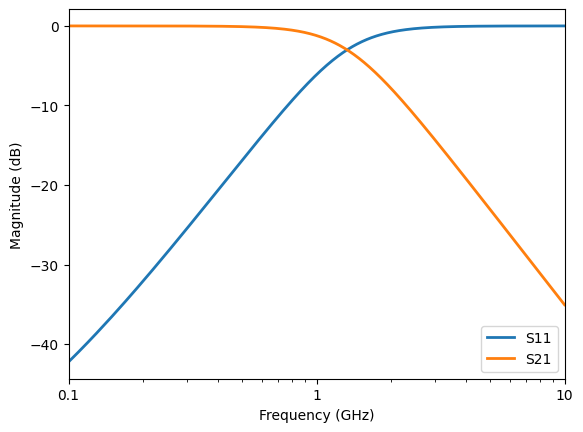

In [12]:
ntw.plot_s_db(m=0, n=0, lw=2, logx=True)  # S11 Response
ntw.plot_s_db(m=1, n=0, lw=2, logx=True)  # S21 Response

### Key Considerations for LC Filters in RF

- **Component modeling accuracy:** At high frequencies, parasitics and layout effects may affect results.
- **Cutoff and bandwidth calculations:** Can be easily adjusted by modifying component values in the model.
- **Topology flexibility:** Supports T-section, π-section, and custom topologies through the circuit builder.
- **Visualization:** S-parameter plots, Smith charts, and circuit diagrams help diagnose performance.

### DefinedGammaZ0 in scikit-rf

**DefinedGammaZ0** is a core media class in scikit-rf that represents a transmission medium with a specified characteristic impedance and propagation constant over a defined frequency range. It provides a foundation for creating both distributed transmission lines and lumped-element models (capacitors, inductors, resistors) in RF circuit simulations.

***

#### Key Concepts

**1. Characteristic Impedance (Z₀)**
Z₀ is the impedance that a wave “sees” as it propagates through an ideal, lossless transmission line. In DefinedGammaZ0, you explicitly set Z₀ (often 50 Ω) as a constant across all frequencies:

```python
media = rf.DefinedGammaZ0(frequency=freq, z0=50)
```

**2. Propagation Constant (γ)**
γ defines how waves attenuate and phase-shift per unit length in the medium. DefinedGammaZ0 allows you to supply any frequency-dependent γ array matching your Frequency object. For a lossless line:

```python
gamma = 1j * freq.w / rf.c  
media = rf.DefinedGammaZ0(frequency=freq, z0=50, gamma=gamma)
```

Here, γ = jβ with β = ω/c.

***

#### Constructor Parameters

- **frequency**: An instance of `skrf.Frequency` defining the frequency points.
- **z0**: Scalar or array of characteristic impedance values (Ω).
- **gamma**: Complex array of propagation constants (1/m) matching the frequency points.
- **name** *(optional)*: A string label for the media.

```python
DefinedGammaZ0(frequency, z0, gamma, name=None)
```

## Next Up
- Parasitics
- Tolerancing